# **Program 1**

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 84.6 MB/s eta 0:00:00


In [6]:
import gensim.downloader as api
m=api.load('word2vec-google-news-300')
print("Similarity",m.similarity("King","Queen"))
print("King-Man+Woman:",m.most_similar(positive=['King','Woman'],negative=['Man'],topn=1)[0])
print("Similar to Paris")
for i,s in m.most_similar("Paris",topn=5):
  print(i,s)
l=['breakfast','lunch','dinner','banana']
print('Odd one out',m.doesnt_match(l))

Similarity 0.5157251
King-Man+Woman: ('Queen', 0.4929387867450714)
Similar to Paris
Parisian 0.6789354681968689
Hopital_Europeen_Georges_Pompidou 0.6536555290222168
Spyker_D##_Peking 0.6336592435836792
France 0.633491039276123
Pantheon_Sorbonne 0.6312517523765564
Odd one out banana


# **Program 2**

In [7]:
!python -m spacy download en_core_web_md'

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl (33.5 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


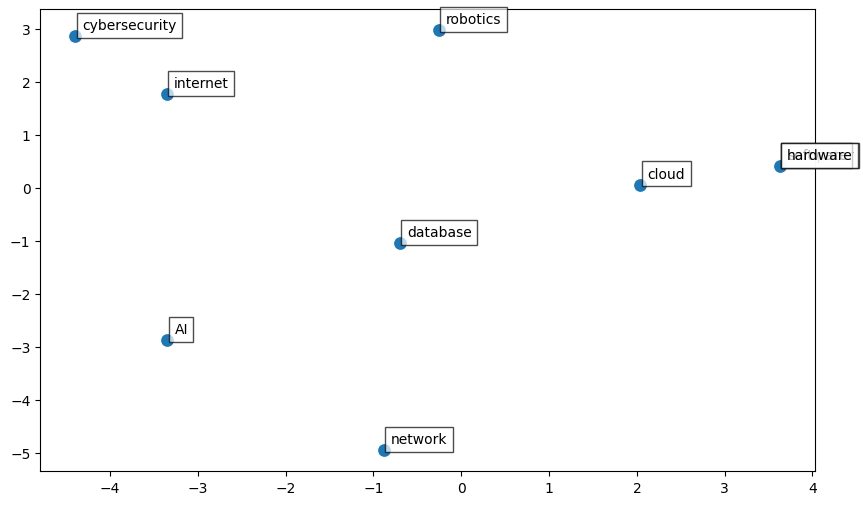

In [14]:
import matplotlib.pyplot as plt, seaborn as sns, spacy, numpy as np
from sklearn.decomposition import PCA
!python -m spacy download en_core_web_md

nlp = spacy.load("en_core_web_md")
words = ["computer","internet","software","hardware","network","AI","cloud","cybersecurity","database","robotics"]

vecs = np.array([nlp(w).vector for w in words])
p = PCA(n_components=2).fit_transform(vecs)

plt.figure(figsize=(10,6))
sns.scatterplot(x=p[:,0], y=p[:,1], s=100)

for i,w in enumerate(words):
    plt.annotate(w,(p[i,0],p[i,1]),xytext=(5,5),textcoords="offset points",
                 bbox=dict(fc="white",alpha=.7))
plt.show()

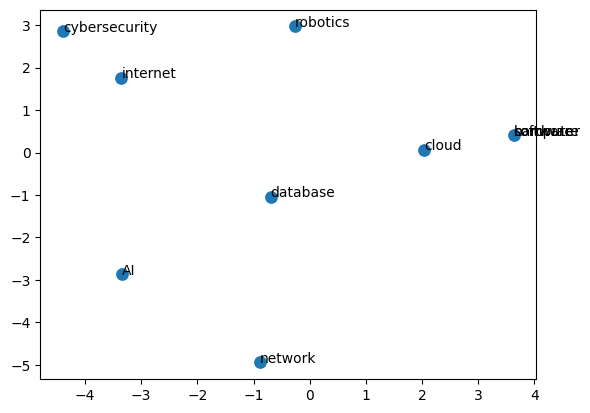

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
nlp=spacy.load('en_core_web_md')
words=["computer","internet","software","hardware","network","AI","cloud","cybersecurity","database","robotics"]
vec=np.array([nlp(w).vector for w in words])
p=PCA(n_components=2).fit_transform(vec)
sns.scatterplot(x=p[:,0],y=p[:,1],s=100)
for i,w in enumerate(words):
  plt.annotate(w,(p[i,0],p[i,1]))
plt.show()

# **program 3**

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


[('gold', 0.9966838955879211), ('both', 0.9966511726379395), ('large', 0.9965356588363647), ('public', 0.9965243935585022), ('capital', 0.9963962435722351)]


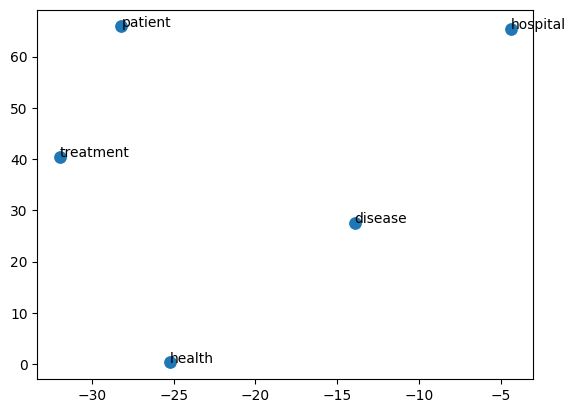

In [31]:
import nltk, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from nltk.corpus import reuters
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

nltk.download("punkt"); nltk.download("reuters"); nltk.download("punkt_tab")

sents = [[w.lower() for w in s if w.isalpha()] for s in reuters.sents()[:5000]]
model = Word2Vec(sents,min_count=2)

term = "disease"
print(model.wv.most_similar(term, topn=5) if term in model.wv else f"{term} not found")

words = ["health","disease","doctor","patient","treatment","medicine","virus","surgery","nurse","hospital"]
vecs = np.array([model.wv[w] for w in words if w in model.wv])

p = TSNE(n_components=2, perplexity=3).fit_transform(vecs)
sns.scatterplot(x=p[:,0], y=p[:,1], s=100)
for i,w in enumerate([w for w in words if w in model.wv]):
    plt.annotate(w,(p[i,0],p[i,1]))
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!


[('workers', 0.996755838394165), ('santa', 0.9966094493865967), ('set', 0.9964724779129028), ('hard', 0.9964205026626587), ('beef', 0.9964017271995544)]


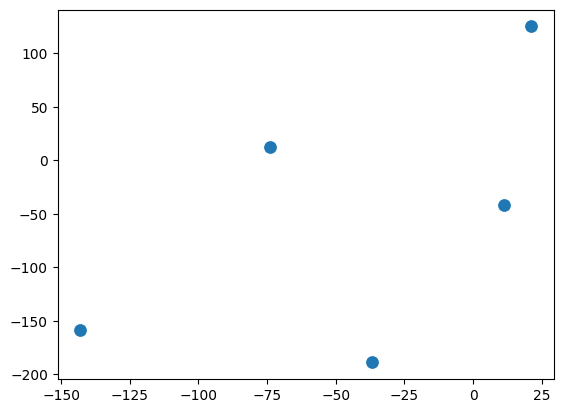

In [36]:
import numpy as np
import nltk
from nltk.corpus import reuters
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('reuters')
sents=[[w.lower() for w in s if w.isalpha()]for s in reuters.sents()[:5000]]
m=Word2Vec(sents,min_count=2)
print(m.wv.most_similar('disease',topn=5))
words=['health','disease','doctor','patient','treatment','medicine','virus','surgery','nurse','hospital']
vecs=np.array([m.wv[w]for w in words if w in m.wv])
p=TSNE(n_components=2,perplexity=3).fit_transform(vecs)
sns.scatterplot(x=p[:,0],y=p[:,1],s=100)
plt.show()


In [ ]:
2